<a href="https://colab.research.google.com/github/hitaxi-04/PDS/blob/main/pr20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

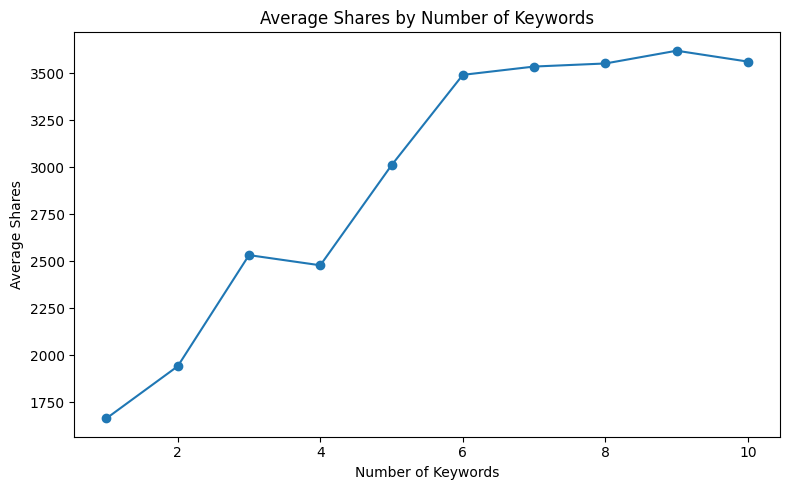

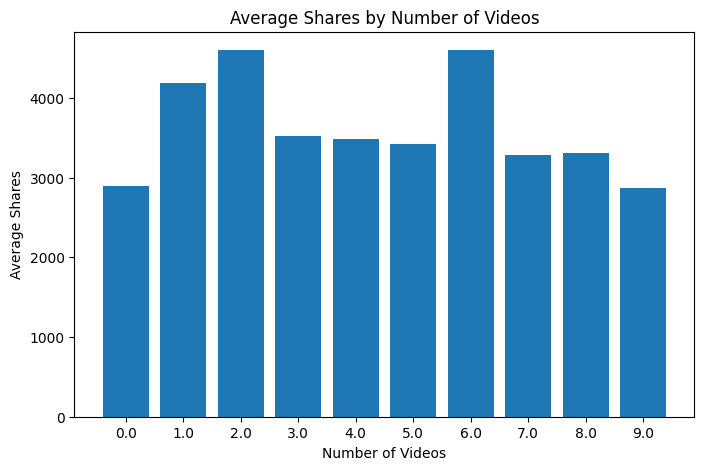

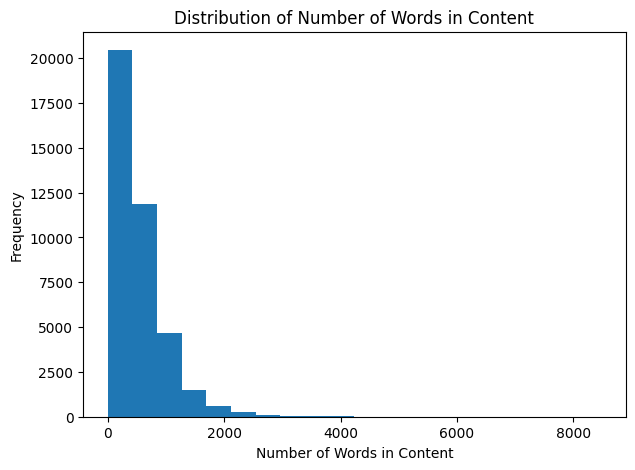

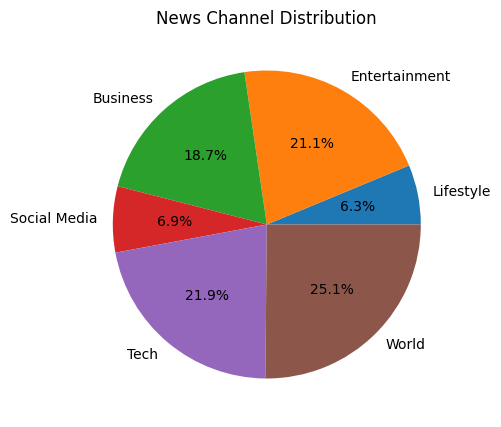

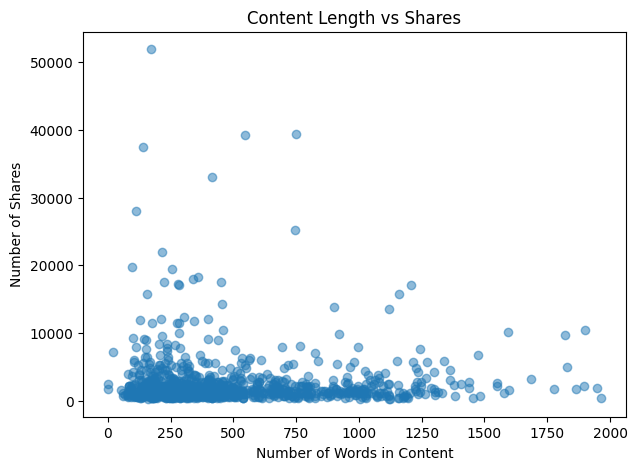

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("OnlineNewsPopularity.csv")

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# line plot
mean_shares = df.groupby("num_keywords")["shares"].mean()
plt.figure(figsize=(8, 5))
plt.plot(mean_shares.index, mean_shares.values, marker="o")
plt.title("Average Shares by Number of Keywords")
plt.xlabel("Number of Keywords")
plt.ylabel("Average Shares")
plt.tight_layout()
plt.show()

# bar chart
video_count = df.groupby("num_videos")["shares"].mean().head(10)
plt.figure(figsize=(8, 5))
plt.bar(video_count.index.astype(str), video_count.values)
plt.title("Average Shares by Number of Videos")
plt.xlabel("Number of Videos")
plt.ylabel("Average Shares")
plt.show()

# histogram
plt.figure(figsize=(7, 5))
plt.hist(df["n_tokens_content"].dropna(), bins=20)
plt.title("Distribution of Number of Words in Content")
plt.xlabel("Number of Words in Content")
plt.ylabel("Frequency")
plt.show()

# pie chart
channel = pd.Series({
    "Lifestyle": df["data_channel_is_lifestyle"].sum(),
    "Entertainment": df["data_channel_is_entertainment"].sum(),
    "Business": df["data_channel_is_bus"].sum(),
    "Social Media": df["data_channel_is_socmed"].sum(),
    "Tech": df["data_channel_is_tech"].sum(),
    "World": df["data_channel_is_world"].sum()
})

plt.figure(figsize=(7, 5))
plt.pie(channel.values,
        labels=channel.index,
        autopct="%1.1f%%")
plt.title("News Channel Distribution")
plt.show()

# scatter plot
sample = df[["n_tokens_content", "shares"]].dropna().head(1000)

plt.figure(figsize=(7, 5))
plt.scatter(sample["n_tokens_content"], sample["shares"], alpha=0.5)
plt.title("Content Length vs Shares")
plt.xlabel("Number of Words in Content")
plt.ylabel("Number of Shares")
plt.show()